# Prototype - Color Segmentation and Feature Extraction

Notebook này thử hướng xử lý khách quan hơn: không dùng JSON như đáp án cuối, mà khai thác tri thức miền từ ảnh.

Giả thuyết ban đầu:
- Anti-A có màu xanh.
- Anti-B có màu vàng.
- Anti-D không màu, nên khó nhận diện bằng màu thuốc thử; cần dựa thêm vào vùng máu/texture.
- Background có thể gây nhiễu, nên phải tạo mask foreground trước khi rút đặc trưng.

Đây là prototype để kiểm tra khả năng segment, chưa phải classifier cuối cùng.

In [4]:
from pathlib import Path
from collections import defaultdict
import json
import math
import re

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

SPLITS = ["train", "valid", "test"]

if IN_COLAB:
    drive.mount("/content/drive")

    # Edit this path if your dataset is stored elsewhere in Google Drive.
    # The folder must contain train/, valid/, test/, and _annotations.coco.json files.
    ROOT = Path("/content/drive/MyDrive/Blood Group Detection.coco")
else:
    ROOT = Path.cwd()

if not all((ROOT / split / "_annotations.coco.json").exists() for split in SPLITS):
    raise FileNotFoundError(
        "COCO dataset not found. If running on Colab, edit ROOT in this cell "
        "to the folder that contains train/, valid/, and test/."
    )

OUTPUT_DIR = ROOT / "processed" / "color_segmentation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 120)

ROOT, OUTPUT_DIR


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(PosixPath('/content/drive/MyDrive/Blood Group Detection.coco'),
 PosixPath('/content/drive/MyDrive/Blood Group Detection.coco/processed/color_segmentation'))

## 1. Load image list

Ta chỉ dùng JSON để lấy danh sách ảnh và label từ tên file. Không dùng pattern bbox `A/B/D` làm đáp án classification.

In [5]:
def parse_blood_group(name: str) -> str:
    match = re.match(r"^(AB|A|B|O)[+-]", name)
    return match.group(0) if match else "UNKNOWN"


def load_images_table() -> pd.DataFrame:
    rows = []
    for split in SPLITS:
        path = ROOT / split / "_annotations.coco.json"
        with path.open("r", encoding="utf-8") as f:
            data = json.load(f)

        for img in data["images"]:
            original_name = img.get("extra", {}).get("name", img["file_name"])
            blood_group = parse_blood_group(original_name)
            rows.append({
                "split": split,
                "image_id": img["id"],
                "file_name": img["file_name"],
                "original_name": original_name,
                "blood_group": blood_group,
                "abo": blood_group[:-1] if blood_group != "UNKNOWN" else "UNKNOWN",
                "rh": blood_group[-1] if blood_group != "UNKNOWN" else "UNKNOWN",
                "width": img["width"],
                "height": img["height"],
                "image_path": str(ROOT / split / img["file_name"]),
            })
    return pd.DataFrame(rows)


images_df = load_images_table()
images_df.head()

,split,image_id,file_name,original_name,blood_group,abo,rh,width,height,image_path
0,train,0,B- (8)_jpg.rf.Y4gSPakmKnxXtqrN20gd.jpg,B- (8).jpg,B-,B,-,2644,868,/content/drive/MyDrive/Blood Group Detection.c...
1,train,1,AB- (59)_jpg.rf.XqNFkV6f7JNjc2LlN7za.jpg,AB- (59).jpg,AB-,AB,-,991,302,/content/drive/MyDrive/Blood Group Detection.c...
2,train,2,A+ (7)_jpg.rf.YMFIioqVqZGqD5EMeCtF.jpg,A+ (7).jpg,A+,A,+,1995,607,/content/drive/MyDrive/Blood Group Detection.c...
3,train,3,A+ (14)_jpg.rf.sSksp3LBJpQi1ohZIjYl.jpg,A+ (14).jpg,A+,A,+,2538,768,/content/drive/MyDrive/Blood Group Detection.c...
4,train,4,B- (95)_jpg.rf.Y9dEJiYDftKo36eOzT7I.jpg,B- (95).jpg,B-,B,-,1019,341,/content/drive/MyDrive/Blood Group Detection.c...


## 2. Color segmentation functions

Ta dùng HSV vì tách màu xanh/vàng ổn hơn RGB. Các ngưỡng bên dưới là ngưỡng ban đầu, cần xem visualization để chỉnh.

Mask chính:
- `anti_a_blue`: vùng xanh/cyan, ứng viên anti-A.
- `anti_b_yellow`: vùng vàng, ứng viên anti-B.
- `blood_red`: vùng đỏ/nâu của máu.
- `foreground`: vùng có màu/không quá trắng, dùng để giảm background.

In [6]:
def read_rgb(path: str, max_side: int = 1200) -> np.ndarray:
    bgr = cv2.imread(path)
    if bgr is None:
        raise FileNotFoundError(path)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    h, w = rgb.shape[:2]
    scale = max(h, w) / max_side
    if scale > 1:
        rgb = cv2.resize(rgb, (int(w / scale), int(h / scale)), interpolation=cv2.INTER_AREA)
    return rgb


def clean_mask(mask: np.ndarray, kernel_size: int = 5, min_area: int = 80) -> np.ndarray:
    mask = mask.astype(np.uint8)
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    cleaned = np.zeros_like(mask)
    for label in range(1, num_labels):
        if stats[label, cv2.CC_STAT_AREA] >= min_area:
            cleaned[labels == label] = 1
    return cleaned.astype(bool)


def segment_image(rgb: np.ndarray) -> dict:
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    h = hsv[:, :, 0]
    s = hsv[:, :, 1]
    v = hsv[:, :, 2]

    # OpenCV hue range is 0..179.
    anti_a_blue = (h >= 80) & (h <= 135) & (s >= 35) & (v >= 35)
    anti_b_yellow = (h >= 15) & (h <= 45) & (s >= 35) & (v >= 45)
    blood_red = (((h <= 12) | (h >= 165)) & (s >= 30) & (v >= 30))

    # General foreground: colored pixels or clearly dark pixels.
    # This avoids treating most white/gray background as useful signal.
    foreground = ((s >= 38) & (v >= 30) & (v <= 250)) | ((s >= 18) & (v <= 150))

    masks = {
        "anti_a_blue": clean_mask(anti_a_blue, kernel_size=5, min_area=120),
        "anti_b_yellow": clean_mask(anti_b_yellow, kernel_size=5, min_area=120),
        "blood_red": clean_mask(blood_red, kernel_size=5, min_area=120),
        "foreground": clean_mask(foreground, kernel_size=5, min_area=200),
    }
    masks["reaction_candidate"] = masks["foreground"] & (masks["blood_red"] | masks["anti_a_blue"] | masks["anti_b_yellow"])
    return masks


def overlay_mask(rgb: np.ndarray, mask: np.ndarray, color=(255, 0, 0), alpha=0.45) -> np.ndarray:
    out = rgb.copy().astype(np.float32)
    color_arr = np.array(color, dtype=np.float32)
    out[mask] = (1 - alpha) * out[mask] + alpha * color_arr
    return out.astype(np.uint8)

## 3. Visual check on representative samples

Đây là cell quan trọng nhất của prototype. Nếu mask xanh/vàng/máu không bám đúng vùng phản ứng, cần chỉnh ngưỡng trước khi dùng feature.

In [7]:
def pick_one_per_group(df: pd.DataFrame) -> pd.DataFrame:
    order = ["A+", "A-", "B+", "B-", "AB+", "AB-", "O+", "O-"]
    rows = []
    for label in order:
        subset = df[df["blood_group"] == label]
        if not subset.empty:
            rows.append(subset.iloc[0])
    return pd.DataFrame(rows)


samples = pick_one_per_group(images_df)
samples[["split", "blood_group", "file_name"]]

,split,blood_group,file_name
2,train,A+,A+ (7)_jpg.rf.YMFIioqVqZGqD5EMeCtF.jpg
5,train,A-,A- (43)_jpg.rf.s3BKqwgQwOZuiTzXcYb7.jpg
21,train,B+,B+ (35)_jpg.rf.GkqQZOcUVB1o6DorvciF.jpg
0,train,B-,B- (8)_jpg.rf.Y4gSPakmKnxXtqrN20gd.jpg
6,train,AB+,AB+ (65)_jpg.rf.zdz4tb5LQL1bIP4xVzJ3.jpg
1,train,AB-,AB- (59)_jpg.rf.XqNFkV6f7JNjc2LlN7za.jpg
13,train,O+,O+ (56)_jpg.rf.t7RHNVBJ2syMHpPEryW6.jpg
636,train,O-,O- (70)_jpg.rf.B1frLoauWbDAmOP7o8d7.jpg


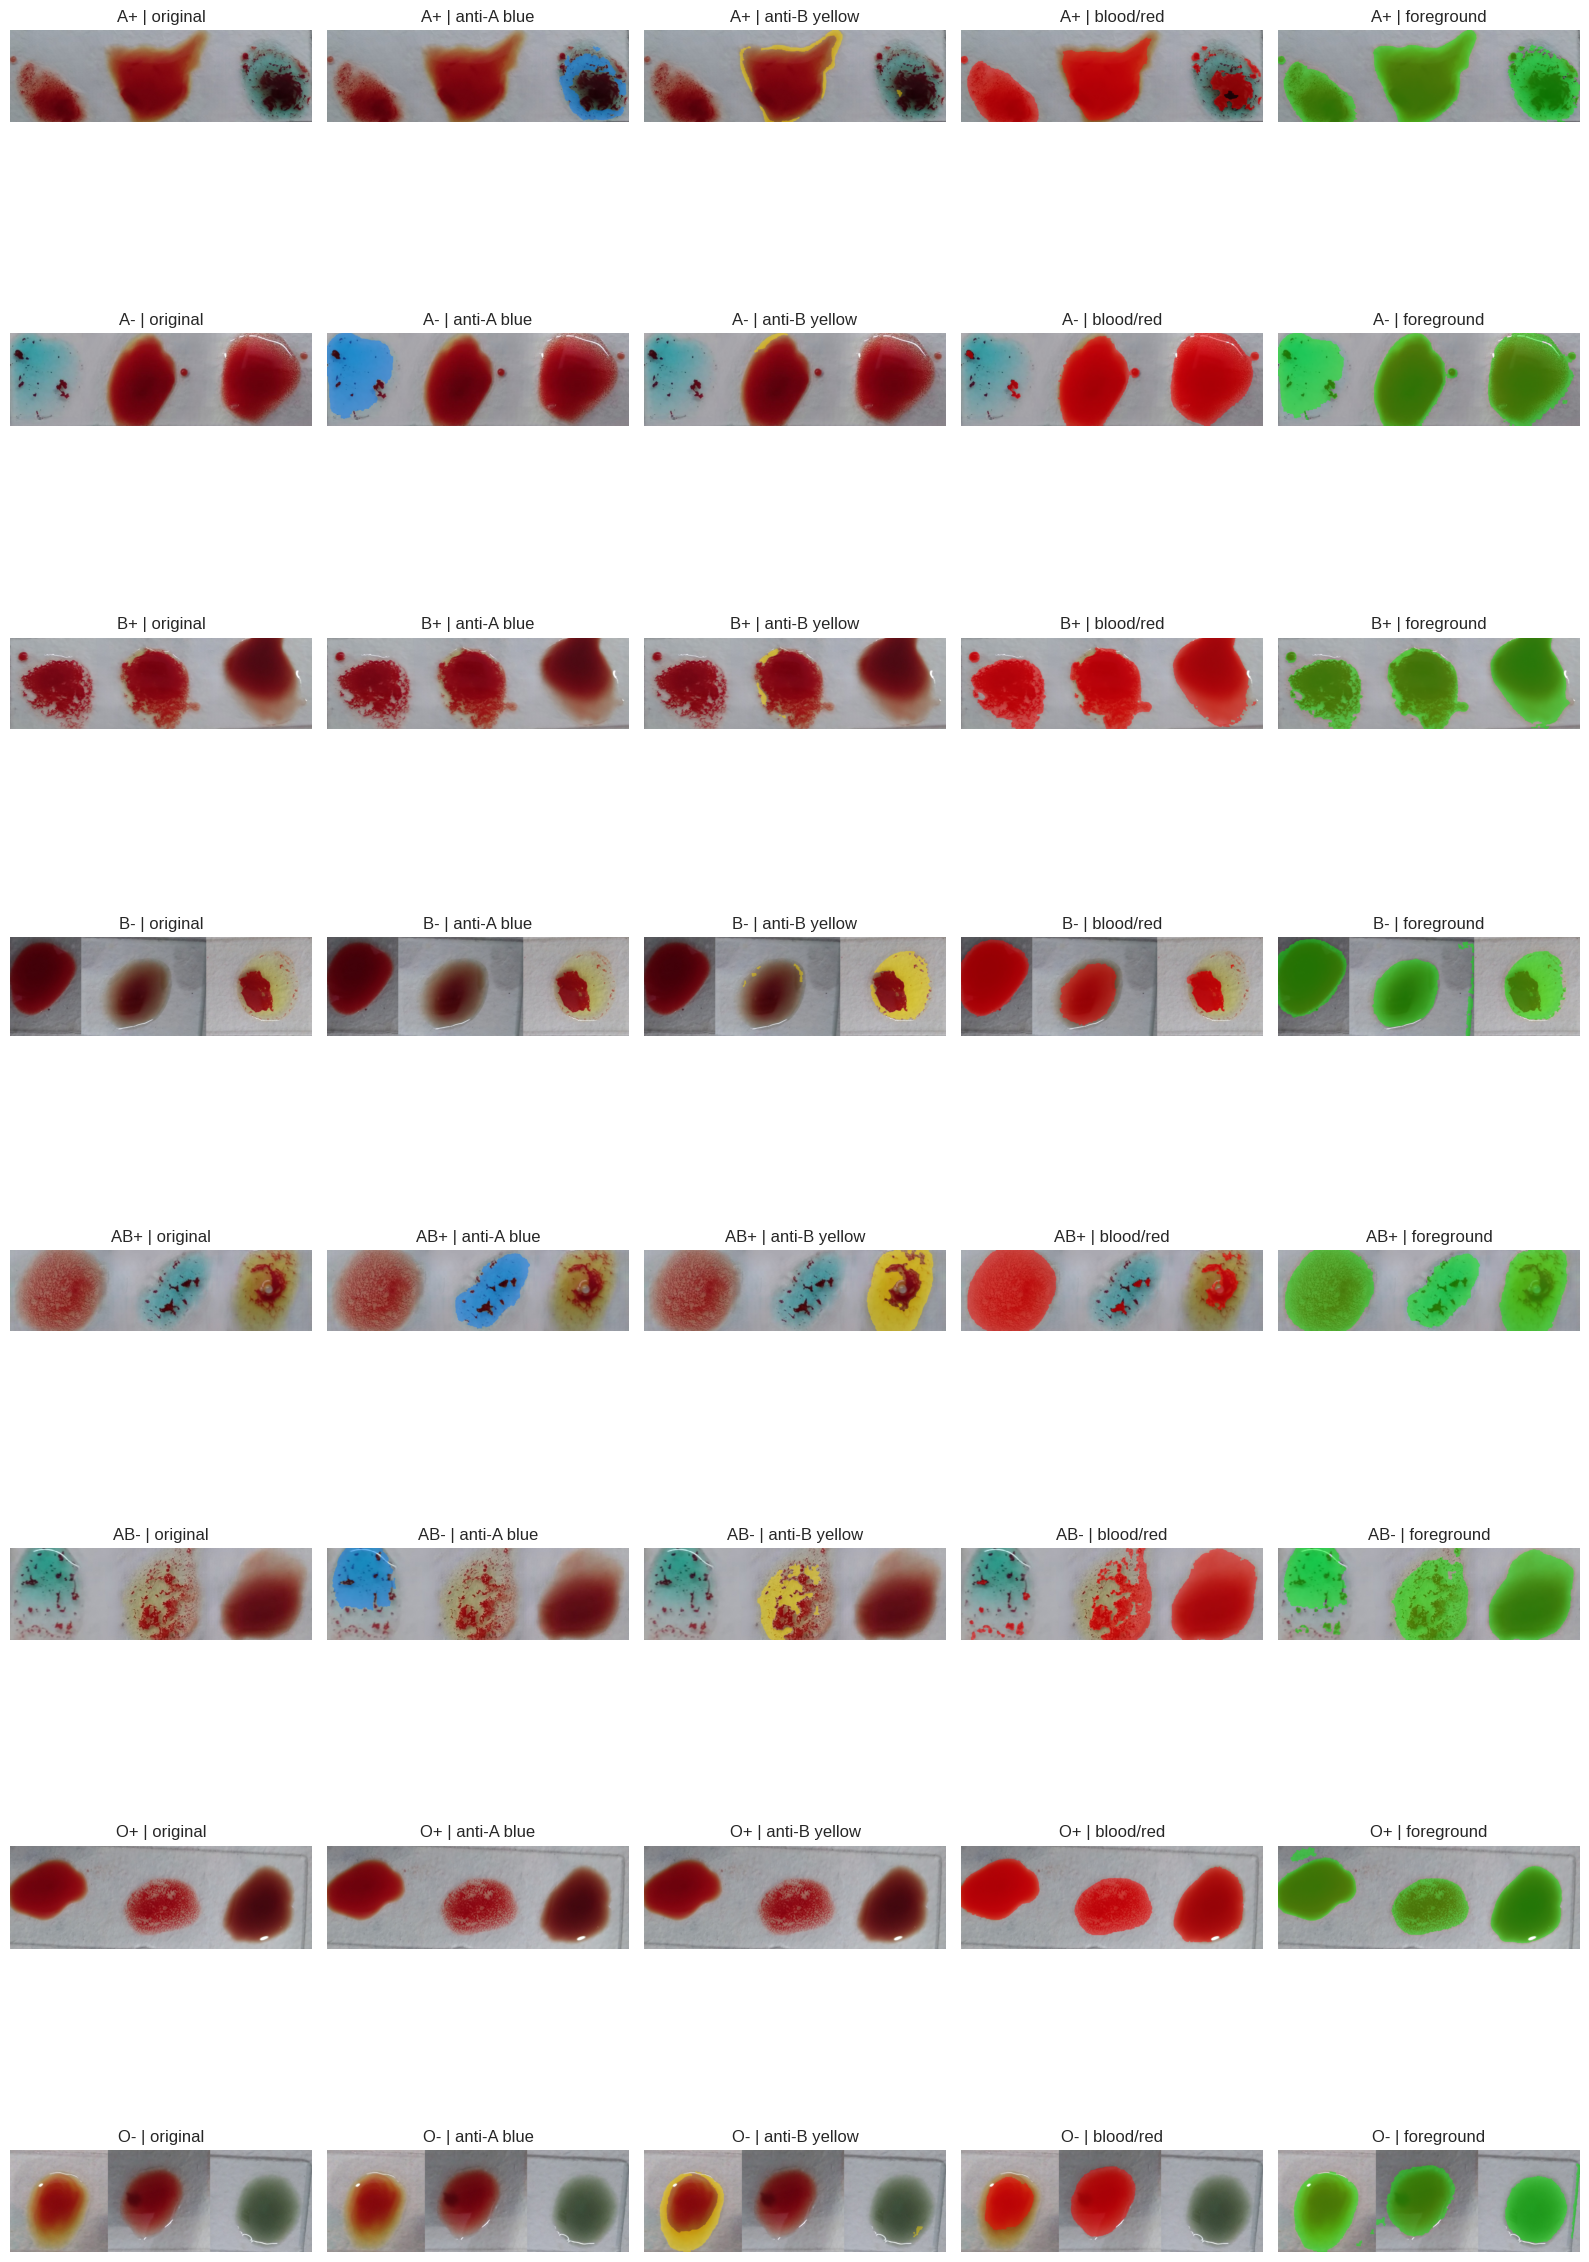

In [8]:
def show_segmentation_grid(samples: pd.DataFrame):
    rows = len(samples)
    cols = 5
    fig, axes = plt.subplots(rows, cols, figsize=(16, 3.2 * rows))
    if rows == 1:
        axes = np.array([axes])

    for r, (_, sample) in enumerate(samples.iterrows()):
        rgb = read_rgb(sample["image_path"])
        masks = segment_image(rgb)
        views = [
            (rgb, "original"),
            (overlay_mask(rgb, masks["anti_a_blue"], (0, 120, 255)), "anti-A blue"),
            (overlay_mask(rgb, masks["anti_b_yellow"], (255, 220, 0)), "anti-B yellow"),
            (overlay_mask(rgb, masks["blood_red"], (255, 0, 0)), "blood/red"),
            (overlay_mask(rgb, masks["foreground"], (0, 255, 0)), "foreground"),
        ]
        for c, (view, title) in enumerate(views):
            axes[r, c].imshow(view)
            axes[r, c].set_title(f"{sample['blood_group']} | {title}")
            axes[r, c].axis("off")
    plt.tight_layout()
    plt.show()


show_segmentation_grid(samples)

## 4. Multi-method mask-level feature extraction

Feature được tính trong từng mask để giảm ảnh hưởng background. Prototype này kết hợp nhiều nhóm đặc trưng thủ công:

- Color statistics: mean/std RGB, HSV, grayscale.
- HSV histogram: phân bố sắc màu, độ bão hòa, độ sáng.
- LBP texture: mô tả texture cục bộ/lốm đốm.
- GLCM texture: contrast, homogeneity, energy, entropy.
- Edge/gradient: Canny edge density, gradient mean/std.
- Blob/shape: số component, diện tích component lớn nhất, contour area/perimeter.

In [9]:
def entropy_from_values(values: np.ndarray, bins: int = 32, value_range=(0, 255)) -> float:
    if values.size == 0:
        return 0.0
    hist, _ = np.histogram(values, bins=bins, range=value_range, density=False)
    total = hist.sum()
    if total == 0:
        return 0.0
    p = hist.astype(np.float64) / total
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())


def entropy_from_gray(gray_values: np.ndarray) -> float:
    if gray_values.size == 0:
        return 0.0
    return entropy_from_values(gray_values, bins=32, value_range=(0, 255))


def normalized_histogram(values: np.ndarray, bins: int, value_range, prefix: str) -> dict:
    if values.size == 0:
        return {f"{prefix}_hist_{i}": 0.0 for i in range(bins)}
    hist, _ = np.histogram(values, bins=bins, range=value_range, density=False)
    total = hist.sum()
    hist = hist.astype(np.float64) / total if total else np.zeros_like(hist, dtype=np.float64)
    return {f"{prefix}_hist_{i}": hist[i] for i in range(bins)}


def lbp_image(gray: np.ndarray) -> np.ndarray:
    center = gray[1:-1, 1:-1]
    neighbors = [
        gray[:-2, :-2], gray[:-2, 1:-1], gray[:-2, 2:],
        gray[1:-1, 2:], gray[2:, 2:], gray[2:, 1:-1],
        gray[2:, :-2], gray[1:-1, :-2],
    ]
    lbp = np.zeros_like(center, dtype=np.uint8)
    for i, n in enumerate(neighbors):
        lbp |= ((n >= center).astype(np.uint8) << i)
    return lbp


def lbp_features(gray: np.ndarray, mask: np.ndarray, prefix: str, bins: int = 16) -> dict:
    if gray.shape[0] < 3 or gray.shape[1] < 3:
        return {f"{prefix}_lbp_hist_{i}": 0.0 for i in range(bins)} | {f"{prefix}_lbp_entropy": 0.0}
    lbp = lbp_image(gray)
    inner_mask = mask[1:-1, 1:-1]
    values = lbp[inner_mask]
    feats = normalized_histogram(values, bins=bins, value_range=(0, 256), prefix=f"{prefix}_lbp")
    feats[f"{prefix}_lbp_entropy"] = entropy_from_values(values, bins=bins, value_range=(0, 256))
    return feats


def glcm_features(gray: np.ndarray, mask: np.ndarray, prefix: str, levels: int = 16) -> dict:
    if gray.shape[0] < 2 or gray.shape[1] < 2 or mask.sum() < 2:
        return {
            f"{prefix}_glcm_contrast": 0.0,
            f"{prefix}_glcm_homogeneity": 0.0,
            f"{prefix}_glcm_energy": 0.0,
            f"{prefix}_glcm_entropy": 0.0,
        }
    quantized = np.clip((gray.astype(np.float32) / 256 * levels).astype(np.int32), 0, levels - 1)
    valid = mask[:, :-1] & mask[:, 1:]
    left = quantized[:, :-1][valid]
    right = quantized[:, 1:][valid]
    matrix = np.zeros((levels, levels), dtype=np.float64)
    for a, b in zip(left, right):
        matrix[a, b] += 1
        matrix[b, a] += 1
    total = matrix.sum()
    if total == 0:
        return {
            f"{prefix}_glcm_contrast": 0.0,
            f"{prefix}_glcm_homogeneity": 0.0,
            f"{prefix}_glcm_energy": 0.0,
            f"{prefix}_glcm_entropy": 0.0,
        }
    p = matrix / total
    i, j = np.indices(p.shape)
    nonzero = p[p > 0]
    return {
        f"{prefix}_glcm_contrast": float(((i - j) ** 2 * p).sum()),
        f"{prefix}_glcm_homogeneity": float((p / (1 + np.abs(i - j))).sum()),
        f"{prefix}_glcm_energy": float(np.sqrt((p ** 2).sum())),
        f"{prefix}_glcm_entropy": float(-(nonzero * np.log2(nonzero)).sum()),
    }


def connected_component_features(mask: np.ndarray) -> dict:
    mask_u8 = mask.astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_u8, connectivity=8)
    areas = [stats[label, cv2.CC_STAT_AREA] for label in range(1, num_labels)]
    if not areas:
        return {"component_count": 0, "largest_component_area": 0, "largest_component_ratio": 0.0}
    largest = max(areas)
    return {
        "component_count": len(areas),
        "largest_component_area": largest,
        "largest_component_ratio": largest / mask.size,
    }


def contour_shape_features(mask: np.ndarray, prefix: str) -> dict:
    mask_u8 = (mask.astype(np.uint8) * 255)
    contours, _ = cv2.findContours(mask_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return {
            f"{prefix}_contour_count": 0,
            f"{prefix}_max_contour_area_ratio": 0.0,
            f"{prefix}_max_contour_perimeter_ratio": 0.0,
            f"{prefix}_max_contour_circularity": 0.0,
        }
    areas = np.array([cv2.contourArea(c) for c in contours], dtype=np.float64)
    perimeters = np.array([cv2.arcLength(c, True) for c in contours], dtype=np.float64)
    idx = int(np.argmax(areas))
    area = areas[idx]
    perimeter = perimeters[idx]
    circularity = (4 * math.pi * area / (perimeter ** 2)) if perimeter > 0 else 0.0
    h, w = mask.shape
    return {
        f"{prefix}_contour_count": len(contours),
        f"{prefix}_max_contour_area_ratio": area / mask.size,
        f"{prefix}_max_contour_perimeter_ratio": perimeter / (2 * (h + w)),
        f"{prefix}_max_contour_circularity": circularity,
    }


def features_for_mask(rgb: np.ndarray, mask: np.ndarray, prefix: str) -> dict:
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 80, 160)
    grad_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    grad_mag = cv2.magnitude(grad_x, grad_y)

    values_rgb = rgb[mask]
    values_hsv = hsv[mask]
    gray_values = gray[mask]
    edge_values = edges[mask]
    grad_values = grad_mag[mask]

    result = {
        f"{prefix}_mask_present": int(mask.any()),
        f"{prefix}_area_ratio": float(mask.mean()),
    }
    result.update({f"{prefix}_{k}": v for k, v in connected_component_features(mask).items()})
    result.update(contour_shape_features(mask, prefix))

    if values_rgb.size == 0:
        for name in ["r_mean", "g_mean", "b_mean", "r_std", "g_std", "b_std", "h_mean", "s_mean", "v_mean", "h_std", "s_std", "v_std", "gray_mean", "gray_std", "edge_density", "gradient_mean", "gradient_std", "entropy"]:
            result[f"{prefix}_{name}"] = 0.0
        result.update(normalized_histogram(np.array([]), bins=12, value_range=(0, 180), prefix=f"{prefix}_hue"))
        result.update(normalized_histogram(np.array([]), bins=8, value_range=(0, 256), prefix=f"{prefix}_sat"))
        result.update(normalized_histogram(np.array([]), bins=8, value_range=(0, 256), prefix=f"{prefix}_val"))
        result.update(lbp_features(gray, mask, prefix))
        result.update(glcm_features(gray, mask, prefix))
        return result

    result.update({
        f"{prefix}_r_mean": values_rgb[:, 0].mean(),
        f"{prefix}_g_mean": values_rgb[:, 1].mean(),
        f"{prefix}_b_mean": values_rgb[:, 2].mean(),
        f"{prefix}_r_std": values_rgb[:, 0].std(),
        f"{prefix}_g_std": values_rgb[:, 1].std(),
        f"{prefix}_b_std": values_rgb[:, 2].std(),
        f"{prefix}_h_mean": values_hsv[:, 0].mean(),
        f"{prefix}_s_mean": values_hsv[:, 1].mean(),
        f"{prefix}_v_mean": values_hsv[:, 2].mean(),
        f"{prefix}_h_std": values_hsv[:, 0].std(),
        f"{prefix}_s_std": values_hsv[:, 1].std(),
        f"{prefix}_v_std": values_hsv[:, 2].std(),
        f"{prefix}_gray_mean": gray_values.mean(),
        f"{prefix}_gray_std": gray_values.std(),
        f"{prefix}_edge_density": float((edge_values > 0).mean()),
        f"{prefix}_gradient_mean": grad_values.mean(),
        f"{prefix}_gradient_std": grad_values.std(),
        f"{prefix}_entropy": entropy_from_gray(gray_values),
    })
    result.update(normalized_histogram(values_hsv[:, 0], bins=12, value_range=(0, 180), prefix=f"{prefix}_hue"))
    result.update(normalized_histogram(values_hsv[:, 1], bins=8, value_range=(0, 256), prefix=f"{prefix}_sat"))
    result.update(normalized_histogram(values_hsv[:, 2], bins=8, value_range=(0, 256), prefix=f"{prefix}_val"))
    result.update(lbp_features(gray, mask, prefix))
    result.update(glcm_features(gray, mask, prefix))
    return result


def extract_image_features(row: pd.Series) -> dict:
    rgb = read_rgb(row["image_path"])
    masks = segment_image(rgb)
    features = {
        "split": row["split"],
        "file_name": row["file_name"],
        "blood_group": row["blood_group"],
        "abo": row["abo"],
        "rh": row["rh"],
        "resized_width": rgb.shape[1],
        "resized_height": rgb.shape[0],
    }
    for name, mask in masks.items():
        features.update(features_for_mask(rgb, mask, name))
    return features

## 5. Extract features

Mặc định cell dưới chạy toàn bộ dataset. Nếu muốn test nhanh trước, đặt `MAX_IMAGES = 100`.

In [10]:
MAX_IMAGES = None  # Example: 100 for quick testing

work_df = images_df if MAX_IMAGES is None else images_df.head(MAX_IMAGES)
feature_rows = []

for i, (_, row) in enumerate(work_df.iterrows(), start=1):
    feature_rows.append(extract_image_features(row))
    if i % 100 == 0:
        print(f"processed {i}/{len(work_df)}")

features_df = pd.DataFrame(feature_rows)
features_path = OUTPUT_DIR / "color_segmentation_features.csv"
features_df.to_csv(features_path, index=False)

features_path, features_df.shape, features_df.head()

processed 100/2072
processed 200/2072
processed 300/2072
processed 400/2072
processed 500/2072
processed 600/2072
processed 700/2072
processed 800/2072
processed 900/2072
processed 1000/2072
processed 1100/2072
processed 1200/2072
processed 1300/2072
processed 1400/2072
processed 1500/2072
processed 1600/2072
processed 1700/2072
processed 1800/2072
processed 1900/2072
processed 2000/2072


(PosixPath('/content/drive/MyDrive/Blood Group Detection.coco/processed/color_segmentation/color_segmentation_features.csv'),
 (2072, 387),
    split                                 file_name blood_group abo rh  \
 0  train    B- (8)_jpg.rf.Y4gSPakmKnxXtqrN20gd.jpg          B-   B  -   
 1  train  AB- (59)_jpg.rf.XqNFkV6f7JNjc2LlN7za.jpg         AB-  AB  -   
 2  train    A+ (7)_jpg.rf.YMFIioqVqZGqD5EMeCtF.jpg          A+   A  +   
 3  train   A+ (14)_jpg.rf.sSksp3LBJpQi1ohZIjYl.jpg          A+   A  +   
 4  train   B- (95)_jpg.rf.Y9dEJiYDftKo36eOzT7I.jpg          B-   B  -   
 
    resized_width  resized_height  anti_a_blue_mask_present  \
 0           1200             393                         0   
 1            991             302                         1   
 2           1200             365                         1   
 3           1199             363                         1   
 4           1019             341                         0   
 
    anti_a_blue_area_ratio  anti_a

## 6. Quick feature sanity checks

Các biểu đồ này giúp xem feature màu có tách được nhóm máu/thuốc thử không. Nếu các cụm chồng lấn quá nhiều, cần cải thiện segmentation hoặc bổ sung annotation.

In [13]:
if "features_df" not in globals():
    features_df = pd.read_csv(OUTPUT_DIR / "color_segmentation_features.csv")

summary_cols = [
    "anti_a_blue_area_ratio",
    "anti_b_yellow_area_ratio",
    "blood_red_area_ratio",
    "foreground_area_ratio",
]
features_df.groupby("blood_group")[summary_cols].median().round(4)

,anti_a_blue_area_ratio,anti_b_yellow_area_ratio,blood_red_area_ratio,foreground_area_ratio
blood_group,,,,
A+,0.0461,0.0100,0.2816,0.3783
A-,0.0525,0.0478,0.2887,0.4567
AB+,0.0358,0.0938,0.2311,0.3827
AB-,0.0469,0.1039,0.2489,0.4490
B+,0.0000,0.0747,0.2945,0.3990
B-,0.0000,0.0945,0.3345,0.4735
O+,0.0000,0.0204,0.3438,0.4194
O-,0.0000,0.0554,0.3490,0.5255


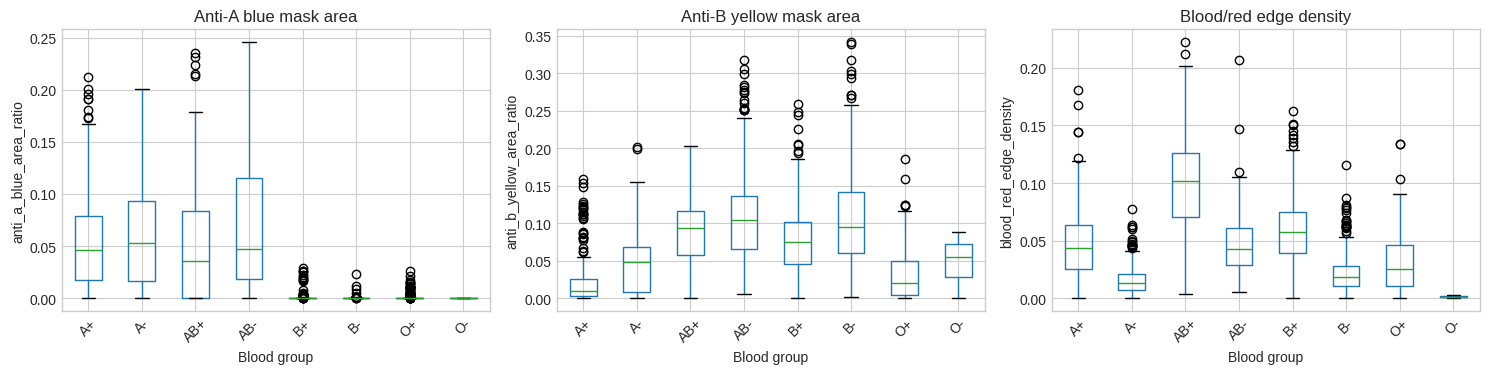

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_specs = [
    ("anti_a_blue_area_ratio", "Anti-A blue mask area"),
    ("anti_b_yellow_area_ratio", "Anti-B yellow mask area"),
    ("blood_red_edge_density", "Blood/red edge density"),
]

for ax, (col, title) in zip(axes, plot_specs):
    features_df.boxplot(column=col, by="blood_group", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Blood group")
    ax.set_ylabel(col)
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("")
plt.tight_layout()
plt.show()

## 7. Interpretation

Nếu segmentation ổn, bước tiếp theo có thể là:

1. Dùng các feature mask-level làm baseline classification.
2. So sánh với baseline dùng toàn ảnh để chứng minh mask giúp giảm background.
3. Nếu anti-D không ổn vì không màu, cần bổ sung feature texture hoặc annotate subset vùng anti-D.
4. Không dùng JSON bbox dương tính làm đáp án cuối, chỉ dùng để tham khảo/so sánh.